In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data/retail_fraud_detection_100k.csv")

In [3]:
data.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [4]:
data.columns.tolist()

['transaction_id',
 'customer_id',
 'transaction_timestamp',
 'transaction_amount',
 'payment_method',
 'device_type',
 'location',
 'merchant_category',
 'is_international',
 'transaction_frequency_24h',
 'avg_transaction_amount_7d',
 'failed_transaction_count_24h',
 'account_age_days',
 'previous_fraud_flag',
 'unusual_amount_flag',
 'unusual_location_flag',
 'multiple_transactions_short_time',
 'high_risk_device_flag',
 'velocity_flag',
 'fraud_flag',
 'fraud_risk']

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  str    
 1   customer_id                       100000 non-null  str    
 2   transaction_timestamp             100000 non-null  str    
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  str    
 5   device_type                       100000 non-null  str    
 6   location                          100000 non-null  str    
 7   merchant_category                 100000 non-null  str    
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h      100000 non-null  int64  
 12  

In [6]:
data['fraud_flag'].value_counts()
data['fraud_flag'].value_counts(normalize=True)

fraud_flag
0    0.52492
1    0.47508
Name: proportion, dtype: float64

In [7]:
data.corr(numeric_only=True)['fraud_flag'].sort_values(ascending=False)

fraud_flag                          1.000000
previous_fraud_flag                 0.423561
unusual_location_flag               0.422911
is_international                    0.422911
multiple_transactions_short_time    0.348364
unusual_amount_flag                 0.329398
velocity_flag                       0.326297
transaction_frequency_24h           0.324047
failed_transaction_count_24h        0.228550
transaction_amount                  0.206105
high_risk_device_flag               0.126393
account_age_days                   -0.002136
avg_transaction_amount_7d          -0.138906
Name: fraud_flag, dtype: float64

In [8]:
data['fraud_risk'].value_counts()
data.groupby('fraud_risk')['fraud_flag'].mean()

fraud_risk
High      1.000000
Low       0.000000
Medium    0.611404
Name: fraud_flag, dtype: float64

In [9]:
data["transaction_timestamp"] = pd.to_datetime(data["transaction_timestamp"])

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   transaction_id                    100000 non-null  str           
 1   customer_id                       100000 non-null  str           
 2   transaction_timestamp             100000 non-null  datetime64[us]
 3   transaction_amount                100000 non-null  float64       
 4   payment_method                    100000 non-null  str           
 5   device_type                       100000 non-null  str           
 6   location                          100000 non-null  str           
 7   merchant_category                 100000 non-null  str           
 8   is_international                  100000 non-null  int64         
 9   transaction_frequency_24h         100000 non-null  int64         
 10  avg_transaction_amount_7d         100000 non

In [11]:
data['hour'] = data['transaction_timestamp'].dt.hour
data['day_of_week'] = data['transaction_timestamp'].dt.dayofweek

In [12]:
data.groupby('hour')['fraud_flag'].mean()

hour
19    0.47508
Name: fraud_flag, dtype: float64

In [13]:
data.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,hour,day_of_week
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,0,0,0,1,0,1,0,Medium,19,2
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,0,0,0,0,0,0,0,Low,19,0
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,1,0,0,0,0,0,0,Medium,19,3
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,1,1,0,1,0,1,1,High,19,1
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,0,0,0,1,0,0,0,Low,19,6


After checking properly we can now see that the time is same for all transactions. So the dataset does not have differents time only dates are different.

In [14]:
data['hour'].nunique()

1

In [15]:
data['day_of_week'].nunique()

7

In [16]:
data.groupby('day_of_week')['fraud_flag'].mean()

day_of_week
0    0.474062
1    0.474451
2    0.472963
3    0.468430
4    0.474437
5    0.479328
6    0.482024
Name: fraud_flag, dtype: float64

In [17]:
data['transaction_date'] = data['transaction_timestamp'].dt.date

In [18]:
data.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,hour,day_of_week,transaction_date
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,0,0,1,0,1,0,Medium,19,2,2026-03-04
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,0,0,0,0,0,0,Low,19,0,2026-03-09
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,0,0,0,0,0,0,Medium,19,3,2026-01-01
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,1,0,1,0,1,1,High,19,1,2025-12-09
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,0,0,1,0,0,0,Low,19,6,2025-11-09


In [19]:
data[['customer_id', 'transaction_timestamp', 'previous_fraud_flag', 'fraud_flag']].sort_values(['customer_id', 'transaction_timestamp']).head(20)

,customer_id,transaction_timestamp,previous_fraud_flag,fraud_flag
33853,C00001,2025-07-20 19:56:24.378396,1,1
69966,C00001,2025-07-30 19:56:25.142173,0,0
98673,C00001,2025-12-25 19:56:25.744232,0,1
67279,C00001,2026-03-28 19:56:25.084273,1,1
56468,C00002,2025-05-06 19:56:24.837259,0,0
21919,C00002,2025-05-19 19:56:24.133473,1,0
61968,C00002,2025-08-16 19:56:24.971842,1,0
60666,C00002,2025-10-16 19:56:24.935565,1,1
33620,C00002,2026-02-17 19:56:24.373795,1,1
47740,C00002,2026-02-20 19:56:24.656342,0,1


In [20]:
data[['customer_id', 'transaction_timestamp', 'unusual_location_flag', 'velocity_flag', 'fraud_flag']].sort_values(['customer_id', 'transaction_timestamp']).head(10)

,customer_id,transaction_timestamp,unusual_location_flag,velocity_flag,fraud_flag
33853,C00001,2025-07-20 19:56:24.378396,0,1,1
69966,C00001,2025-07-30 19:56:25.142173,0,0,0
98673,C00001,2025-12-25 19:56:25.744232,1,1,1
67279,C00001,2026-03-28 19:56:25.084273,1,0,1
56468,C00002,2025-05-06 19:56:24.837259,0,0,0
21919,C00002,2025-05-19 19:56:24.133473,0,1,0
61968,C00002,2025-08-16 19:56:24.971842,0,0,0
60666,C00002,2025-10-16 19:56:24.935565,0,0,1
33620,C00002,2026-02-17 19:56:24.373795,1,0,1
47740,C00002,2026-02-20 19:56:24.656342,1,1,1


In [21]:
data.groupby(['is_international', 'high_risk_device_flag'])['fraud_flag'].mean()

is_international  high_risk_device_flag
0                 0                        0.242171
                  1                        0.466601
1                 0                        0.667598
                  1                        0.860028
Name: fraud_flag, dtype: float64

In [22]:
data['transaction_amount'].describe()

count    100000.000000
mean        120.475407
std         119.787252
min           0.000000
25%          34.820000
50%          84.130000
75%         167.520000
max        1548.520000
Name: transaction_amount, dtype: float64

In [23]:
data[data['transaction_amount'] > data['transaction_amount'].quantile(0.999)]

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,hour,day_of_week,transaction_date
135,T0000136,C22427,2025-12-04 19:56:23.682164,980.69,Credit Card,Tablet,USA,Luxury,0,6,...,1,0,0,0,0,1,Medium,19,3,2025-12-04
3467,T0003468,C13619,2025-10-19 19:56:23.750172,961.84,Apple Pay,Desktop,USA,Travel,1,9,...,1,1,1,0,0,1,High,19,6,2025-10-19
4720,T0004721,C08250,2025-11-09 19:56:23.776413,971.36,Apple Pay,Mobile,Germany,Fashion,1,11,...,1,1,1,0,1,1,High,19,6,2025-11-09
5186,T0005187,C08245,2025-08-17 19:56:23.786393,859.16,PayPal,Desktop,Germany,Groceries,1,1,...,1,1,0,0,0,1,High,19,6,2025-08-17
5420,T0005421,C07849,2025-09-27 19:56:23.791380,1106.42,Credit Card,Desktop,Canada,Groceries,0,12,...,1,0,1,0,1,1,High,19,5,2025-09-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96116,T0096117,C26616,2025-10-04 19:56:25.689274,861.28,Google Pay,Tablet,UK,Fashion,0,9,...,1,0,1,0,0,0,Medium,19,5,2025-10-04
96238,T0096239,C15833,2025-09-23 19:56:25.691859,847.56,Google Pay,Mobile,USA,Travel,0,7,...,1,0,0,0,0,1,Medium,19,1,2025-09-23
96309,T0096310,C12430,2026-01-09 19:56:25.693377,822.65,Credit Card,Mobile,USA,Travel,1,1,...,1,1,0,0,0,0,Medium,19,4,2026-01-09
98602,T0098603,C04841,2025-12-03 19:56:25.742423,1060.88,Credit Card,Mobile,USA,Electronics,0,14,...,1,0,1,0,1,1,High,19,2,2025-12-03


In [24]:
data.duplicated().sum()

np.int64(0)

In [25]:
data['transaction_id'].duplicated().sum()

np.int64(0)

In [26]:
data['customer_id'].nunique()

28955

<Axes: xlabel='fraud_flag', ylabel='transaction_amount'>

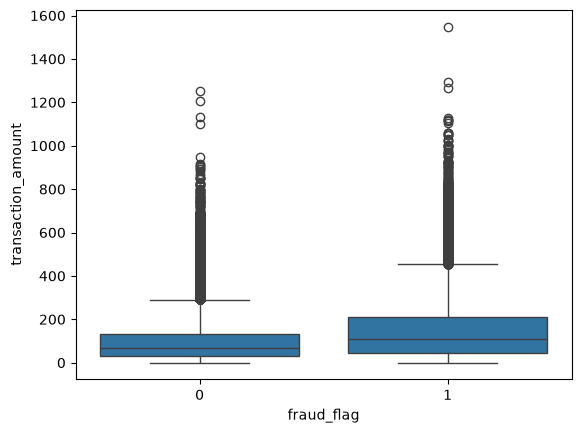

In [27]:
sns.boxplot(data=data, x='fraud_flag', y='transaction_amount')

<Axes: xlabel='transaction_timestamp'>

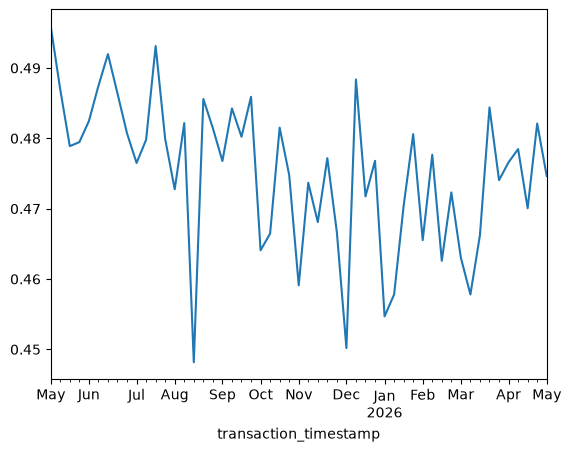

In [28]:
data.set_index('transaction_timestamp').resample('W')['fraud_flag'].mean().plot()

The above graph only goes on to show that there might be no co-relation between fraud flag and time. As there seems to not be a specific pattern.

In [29]:
data["log_transaction_amount"] = np.log1p(data["transaction_amount"])

In [30]:
data.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,hour,day_of_week,transaction_date,log_transaction_amount
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,0,1,0,1,0,Medium,19,2,2026-03-04,4.048475
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,0,0,0,0,0,Low,19,0,2026-03-09,3.061052
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,0,0,0,0,0,Medium,19,3,2026-01-01,3.906407
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,0,1,0,1,1,High,19,1,2025-12-09,5.040970
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,0,1,0,0,0,Low,19,6,2025-11-09,4.756345


In [31]:
data[['transaction_amount', 'log_transaction_amount']].describe()

,transaction_amount,log_transaction_amount
count,100000.000000,100000.000000
mean,120.475407,4.262634
std,119.787252,1.185999
min,0.000000,0.000000
25%,34.820000,3.578506
50%,84.130000,4.444179
75%,167.520000,5.127054
max,1548.520000,7.345700


In [32]:
data["intl_and_highrisk_device"] = data["is_international"] * data["high_risk_device_flag"]